# Bahdanau 注意力

目标：用 PyTorch **从零实现** d2l 10.4 Bahdanau Attention 的核心思想：
- **加性注意力打分函数** 
- 在 **Seq2Seq 解码器**每一步用注意力生成上下文向量 $c_{t'}$
- 训练一个 **toy 翻译任务**（把输入序列反转输出），并可视化注意力热力图

参考（读原文思路）：[d2l 10.4 Bahdanau 注意力](https://zh.d2l.ai/chapter_attention-mechanisms/bahdanau-attention.html)

In [1]:
import math
import random
from dataclasses import dataclass

import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

## 1. 工具函数：mask / masked_softmax / 可视化

注意力里常见需求：
- mini-batch 里序列长度不同，需要 padding
- softmax 时要把 padding 位置 mask 掉（权重=0）

In [2]:
def sequence_mask(X: torch.Tensor, valid_lens: torch.Tensor, value: float = 0.0):
    """把每行超出 valid_lens 的位置填成 value。

    X: (N, T)
    valid_lens: (N,)
    """
    maxlen = X.size(1)
    mask = torch.arange(maxlen, device=X.device)[None, :] < valid_lens[:, None]
    X = X.clone()
    X[~mask] = value
    return X

def masked_softmax(scores: torch.Tensor, valid_lens: torch.Tensor | None):
    """对最后一维做 softmax，并按 valid_lens mask。

    scores: (B, Q, K)
    valid_lens: (B,) 或 (B, Q)
    return: (B, Q, K)
    """
    if valid_lens is None:
        return F.softmax(scores, dim=-1)

    B, Q, K = scores.shape
    if valid_lens.dim() == 1:
        # (B,) -> (B*Q,)
        valid_lens = valid_lens.repeat_interleave(Q)
    else:
        valid_lens = valid_lens.reshape(-1)

    scores2d = scores.reshape(-1, K)
    scores2d = sequence_mask(scores2d, valid_lens, value=-1e6)
    return F.softmax(scores2d.reshape(B, Q, K), dim=-1)

def show_heatmap(attn: torch.Tensor, xlabel='Key positions', ylabel='Query positions', title=None, figsize=(6, 4)):
    """attn: (T_query, T_key)"""
    attn_np = attn.detach().cpu().numpy()
    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
    im = ax.imshow(attn_np, cmap='Reds', aspect='auto')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    fig.colorbar(im, ax=ax, shrink=0.8)
    plt.show()

## 2. 加性注意力（Bahdanau / Additive Attention）模块

打分函数（每个 query-key 对应一个标量分数）：

$$a(\mathbf{q}, \mathbf{k}) = \mathbf{w}_v^\top \tanh(\mathbf{W}_q\mathbf{q} + \mathbf{W}_k\mathbf{k})$$

注意：
- score 是 **标量**，形状 (B, Q, K)
- 权重 $\alpha$ 经过 softmax 仍是 (B, Q, K)
- 输出 context 是对 values 加权和，形状 (B, Q, H)（是向量）

In [3]:
class AdditiveAttention(nn.Module):
    def __init__(self, key_size: int, query_size: int, num_hiddens: int, dropout: float):
        super().__init__()
        self.W_k = nn.Linear(key_size, num_hiddens, bias=False)
        self.W_q = nn.Linear(query_size, num_hiddens, bias=False)
        self.w_v = nn.Linear(num_hiddens, 1, bias=False)
        self.dropout = nn.Dropout(dropout)
        self.attention_weights = None

    def forward(self, queries: torch.Tensor, keys: torch.Tensor, values: torch.Tensor, valid_lens: torch.Tensor | None):
        """
        queries: (B, Q, query_size)
        keys:    (B, K, key_size)
        values:  (B, K, value_size) 这里通常 value_size == key_size == H
        valid_lens: (B,) 或 (B, Q)
        return: (B, Q, value_size)
        """
        queries = self.W_q(queries)  # (B, Q, H)
        keys = self.W_k(keys)        # (B, K, H)

        # 广播相加 -> (B, Q, K, H)
        features = torch.tanh(queries.unsqueeze(2) + keys.unsqueeze(1))
        scores = self.w_v(features).squeeze(-1)  # (B, Q, K)

        self.attention_weights = masked_softmax(scores, valid_lens)
        return torch.bmm(self.dropout(self.attention_weights), values)


## 3. Toy 任务：把输入序列反转输出（Seq2Seq + Bahdanau Attention）

我们做一个极简任务来观察注意力：
- 输入：长度 3~7 的整数序列（token）
- 输出：把输入反转

这样注意力应该学到一种“对齐”：解码第 t 步时更关注编码器的某个位置。

In [4]:
PAD = 0
BOS = 10
EOS = 11
VOCAB_SIZE = 12  # 0..11

def make_example(min_len=3, max_len=7, token_min=1, token_max=9):
    L = random.randint(min_len, max_len)
    src = [random.randint(token_min, token_max) for _ in range(L)]
    tgt = list(reversed(src))
    return src, tgt

def pad_batch(seqs, pad_value=PAD):
    lens = torch.tensor([len(s) for s in seqs], dtype=torch.long)
    maxlen = int(lens.max())
    out = torch.full((len(seqs), maxlen), pad_value, dtype=torch.long)
    for i, s in enumerate(seqs):
        out[i, :len(s)] = torch.tensor(s, dtype=torch.long)
    return out, lens

def make_batch(batch_size=32):
    srcs, tgts = [], []
    for _ in range(batch_size):
        src, tgt = make_example()
        srcs.append(src + [EOS])
        tgts.append([BOS] + tgt + [EOS])
    src_pad, src_lens = pad_batch(srcs, PAD)
    tgt_pad, tgt_lens = pad_batch(tgts, PAD)
    return src_pad, src_lens, tgt_pad, tgt_lens

src_pad, src_lens, tgt_pad, tgt_lens = make_batch(4)
src_pad, src_lens, tgt_pad, tgt_lens

(tensor([[ 6,  5,  7,  2,  3,  4,  5, 11],
         [ 6,  8,  2, 11,  0,  0,  0,  0],
         [ 3,  3,  7,  2,  4,  9, 11,  0],
         [ 3,  8,  8,  6,  7,  4, 11,  0]]),
 tensor([8, 4, 7, 7]),
 tensor([[10,  5,  4,  3,  2,  7,  5,  6, 11],
         [10,  2,  8,  6, 11,  0,  0,  0,  0],
         [10,  9,  4,  2,  7,  3,  3, 11,  0],
         [10,  4,  7,  6,  8,  8,  3, 11,  0]]),
 tensor([9, 5, 8, 8]))

## 4. 编码器 / 带注意力的解码器

- 编码器：Embedding + GRU，输出 `enc_outputs`（每个 time step 的隐状态）
- 解码器：每一步用上一步 hidden 当 query，对 `enc_outputs` 做注意力得到 context，再和当前 token embedding 拼起来喂给 GRU。

In [5]:
class Seq2SeqEncoder(nn.Module):
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers=1, dropout=0.0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=PAD)
        self.rnn = nn.GRU(embed_size, num_hiddens, num_layers=num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0.0)

    def forward(self, X, valid_lens):
        # X: (B, T_src)
        emb = self.embedding(X)  # (B, T_src, E)
        outputs, state = self.rnn(emb)  # outputs: (B, T_src, H); state: (L, B, H)
        return outputs, state

class Seq2SeqAttentionDecoder(nn.Module):
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers=1, dropout=0.0):
        super().__init__()
        self.attention = AdditiveAttention(num_hiddens, num_hiddens, num_hiddens, dropout)
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=PAD)
        self.rnn = nn.GRU(embed_size + num_hiddens, num_hiddens, num_layers=num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.fc = nn.Linear(num_hiddens, vocab_size)

    def init_state(self, enc_outputs, enc_state, enc_valid_lens):
        # enc_outputs: (B, T_src, H), enc_state: (L, B, H)
        return enc_outputs, enc_state, enc_valid_lens

    def forward(self, X, state):
        """
        X: (B, T_tgt)  这里是 teacher forcing 输入（通常以 BOS 开头）
        return logits: (B, T_tgt, V), attention: (B, T_tgt, T_src)
        """
        enc_outputs, hidden, enc_valid_lens = state
        B, T_tgt = X.shape
        emb = self.embedding(X)  # (B, T_tgt, E)

        logits = []
        attns = []
        for t in range(T_tgt):
            x_t = emb[:, t:t+1, :]  # (B, 1, E)
            query = hidden[-1].unsqueeze(1)  # (B, 1, H)
            context = self.attention(query, enc_outputs, enc_outputs, enc_valid_lens)  # (B, 1, H)
            attn_w = self.attention.attention_weights  # (B, 1, T_src)

            rnn_input = torch.cat([context, x_t], dim=-1)  # (B, 1, H+E)
            out, hidden = self.rnn(rnn_input, hidden)      # out: (B, 1, H)
            logit = self.fc(out.squeeze(1))               # (B, V)

            logits.append(logit)
            attns.append(attn_w.squeeze(1))  # (B, T_src)

        logits = torch.stack(logits, dim=1)  # (B, T_tgt, V)
        attns = torch.stack(attns, dim=1)    # (B, T_tgt, T_src)
        return logits, attns


## 5. 训练：masked loss（忽略 PAD）

我们对每个时间步做交叉熵，但 **PAD 位置不计入 loss**。

In [6]:
def masked_cross_entropy(logits, targets, valid_lens):
    """
    logits: (B, T, V)
    targets: (B, T)
    valid_lens: (B,) 这里指 targets 的有效长度（不含 PAD）
    """
    B, T, V = logits.shape
    loss = F.cross_entropy(logits.reshape(B*T, V), targets.reshape(B*T), reduction='none')
    loss = loss.reshape(B, T)

    mask = torch.arange(T, device=logits.device)[None, :] < valid_lens[:, None]
    loss = (loss * mask).sum(dim=1) / valid_lens
    return loss.mean()

@dataclass
class Config:
    embed_size: int = 32
    num_hiddens: int = 64
    num_layers: int = 1
    dropout: float = 0.1
    lr: float = 1e-3
    batch_size: int = 64
    steps: int = 800

cfg = Config()

encoder = Seq2SeqEncoder(VOCAB_SIZE, cfg.embed_size, cfg.num_hiddens, cfg.num_layers, cfg.dropout).to(device)
decoder = Seq2SeqAttentionDecoder(VOCAB_SIZE, cfg.embed_size, cfg.num_hiddens, cfg.num_layers, cfg.dropout).to(device)

params = list(encoder.parameters()) + list(decoder.parameters())
opt = torch.optim.Adam(params, lr=cfg.lr)

def train_step():
    encoder.train(); decoder.train()
    src, src_lens, tgt, tgt_lens = make_batch(cfg.batch_size)
    src, src_lens, tgt, tgt_lens = src.to(device), src_lens.to(device), tgt.to(device), tgt_lens.to(device)

    # decoder 输入 X 是 tgt 的前 T-1（teacher forcing），标签是 tgt 的后 T-1
    X_dec = tgt[:, :-1]
    y = tgt[:, 1:]
    y_lens = tgt_lens - 1

    enc_outputs, enc_state = encoder(src, src_lens)
    state = decoder.init_state(enc_outputs, enc_state, src_lens)
    logits, attn = decoder(X_dec, state)

    loss = masked_cross_entropy(logits, y, y_lens)
    opt.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(params, 1.0)
    opt.step()
    return float(loss.detach().cpu())

losses = []
for step in range(1, cfg.steps + 1):
    l = train_step()
    losses.append(l)
    if step % 100 == 0:
        print(f'step {step:4d} | loss {np.mean(losses[-100:]):.4f}')


step  100 | loss 1.7520
step  200 | loss 0.4386
step  300 | loss 0.1219
step  400 | loss 0.0657
step  500 | loss 0.0452
step  600 | loss 0.0341
step  700 | loss 0.0274
step  800 | loss 0.0244


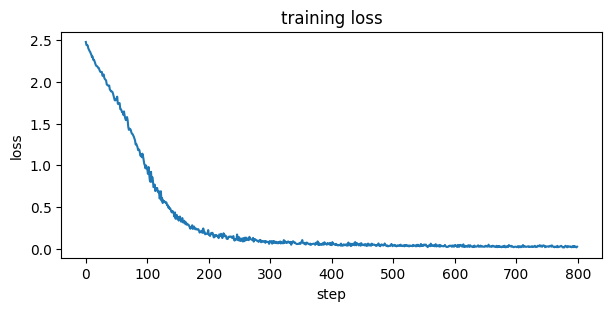

In [7]:
plt.figure(figsize=(6,3), constrained_layout=True)
plt.plot(losses)
plt.title('training loss')
plt.xlabel('step')
plt.ylabel('loss')
plt.show()

## 6. 推理（greedy decode）+ 可视化注意力

我们对一个样本做贪心解码，并画出 attention heatmap：
- 横轴：encoder 的 key 位置（输入序列位置）
- 纵轴：decoder 的 query 位置（输出步数）
颜色越深表示该输出步更关注该输入位置。

SRC: [2, 3, 4]
TGT (gold reverse): [4, 3, 2]
PRED (incl BOS/EOS): [10, 4, 3, 4, 4, 3, 2, 11]


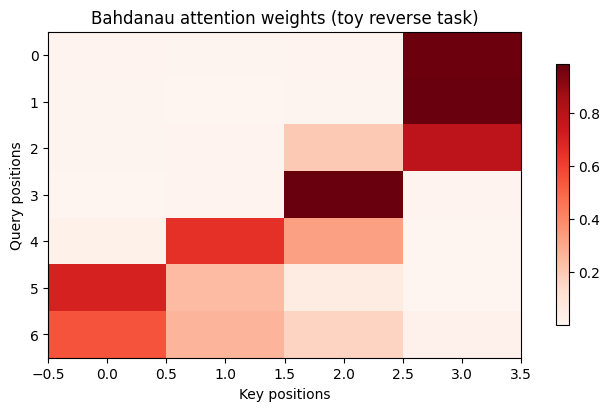

In [8]:
def greedy_decode(src_tokens, max_len=20):
    encoder.eval(); decoder.eval()
    src = torch.tensor([src_tokens + [EOS]], dtype=torch.long, device=device)
    src_lens = torch.tensor([len(src_tokens) + 1], dtype=torch.long, device=device)

    enc_outputs, enc_state = encoder(src, src_lens)
    state = decoder.init_state(enc_outputs, enc_state, src_lens)

    ys = [BOS]
    attn_steps = []
    hidden = state[1]

    for _ in range(max_len):
        x = torch.tensor([[ys[-1]]], dtype=torch.long, device=device)  # (1,1)
        emb = decoder.embedding(x)  # (1,1,E)

        query = hidden[-1].unsqueeze(1)
        context = decoder.attention(query, enc_outputs, enc_outputs, src_lens)
        attn_w = decoder.attention.attention_weights.squeeze(1).squeeze(0)  # (T_src,)
        attn_steps.append(attn_w)

        rnn_input = torch.cat([context, emb], dim=-1)
        out, hidden = decoder.rnn(rnn_input, hidden)
        logit = decoder.fc(out.squeeze(1))
        nxt = int(torch.argmax(logit, dim=-1).item())
        ys.append(nxt)
        if nxt == EOS:
            break

    attn_mat = torch.stack(attn_steps, dim=0) if attn_steps else torch.zeros((0, src.shape[1]), device=device)
    return ys, attn_mat

def pretty_tokens(seq):
    return ' '.join(map(str, seq))

src_ex, tgt_ex = make_example()
pred, attn = greedy_decode(src_ex)

print('SRC:', src_ex)
print('TGT (gold reverse):', list(reversed(src_ex)))
print('PRED (incl BOS/EOS):', pred)

# 画热力图：去掉最后的 EOS 列没关系，但这里保留 encoder 的 EOS 位置更直观
show_heatmap(attn, title='Bahdanau attention weights (toy reverse task)')

## 7. 你应该重点理解的 3 个形状

在 Bahdanau 注意力里（本 notebook 的实现）：
- `enc_outputs`: (B, T_src, H)  —— 编码器每个位置的隐状态（既是 key 也是 value）
- `attention_weights`: (B, 1, T_src) —— 某一步解码时对每个输入位置的权重（热力图画的就是它沿时间堆起来）
- `context`: (B, 1, H) —— 用权重对 enc_outputs 加权求和得到的上下文向量

读 d2l 原文时，把它们对应到公式 (10.4.1)：

$$c_{t'} = \sum_{t=1}^{T} \alpha(s_{t'-1}, h_t)\,h_t$$

其中：
- query = $s_{t'-1}$（解码器上一时刻隐状态）
- key/value = $h_t$（编码器各时刻隐状态）
- $\alpha$ 就是 attention_weights（softmax 后的权重）